# Tutorial: Research Backtester Basics

This notebook shows the basic backtester workflow:

1. Load OHLC data.
2. Build volume bars with `numba_tools.volume_grouper()`.
3. Build a simple position series on the grouped data.
4. Convert the grouped strategy into a transaction frame with `no_stop()`.
5. Upsample grouped blips back to the original 30-second frame.
6. Evaluate both paths with `perf()`.

The example intentionally uses a simple moving-average strategy. It is only here to demonstrate the API and timing pattern.

## Data source

The examples use continuous NQ futures from the local Arctic store:

```python
store = ArcticStore("contfutures")
df = store.store.read("NQ")
df = df.loc["2023-06-01":]
```

Any other OHLC dataframe can be substituted. The examples expect at least `open`, `high`, `low`, and `close`; `volume` and `barCount` are used when available.

In [1]:
import numpy as np
import pandas as pd

from haymaker.datastore import ArcticStore

store = ArcticStore("contfutures")
item = store.store.read("NQ")
df = item.data if hasattr(item, "data") else item
df = df.loc["2023-06-01":].copy()
df = df.sort_index()

df.head()

Library created, but couldn't enable sharding: no such command: 'enablesharding', full error: {'ok': 0.0, 'errmsg': "no such command: 'enablesharding'", 'code': 59, 'codeName': 'CommandNotFound'}. This is OK if you're not 'admin'


,open,high,low,close,volume,average,barCount
date,,,,,,,
2023-06-01 00:00:00+00:00,17073.25,17073.50,17070.75,17072.75,81.0,17072.125,65
2023-06-01 00:00:30+00:00,17072.25,17072.50,17071.25,17071.25,13.0,17071.925,10
2023-06-01 00:01:00+00:00,17071.00,17072.75,17067.75,17070.00,82.0,17069.975,53
2023-06-01 00:01:30+00:00,17069.75,17070.25,17068.25,17069.75,61.0,17069.050,48
2023-06-01 00:02:00+00:00,17070.50,17073.50,17070.50,17072.75,59.0,17072.375,45


In [2]:
required = ["open", "high", "low", "close"]
optional = [column for column in ["volume", "barCount", "average"] if column in df.columns]
df = df[required + optional].dropna().copy()

# The NQ 30-second slice is large. Keep the tutorial responsive; set this
# to None if you want to run every example on the full history.
max_rows = 100_000
if max_rows is not None and len(df) > max_rows:
    df = df.tail(max_rows).copy()

df.tail()

,open,high,low,close,volume,barCount,average
date,,,,,,,
2026-03-24 08:32:30+00:00,24405.00,24407.25,24395.50,24398.50,100.0,65,24403.250
2026-03-24 08:33:00+00:00,24401.50,24404.75,24395.50,24397.75,57.0,46,24400.575
2026-03-24 08:33:30+00:00,24396.25,24402.25,24385.25,24387.25,78.0,60,24394.300
2026-03-24 08:34:00+00:00,24387.75,24395.75,24387.75,24391.75,39.0,35,24392.900
2026-03-24 08:34:30+00:00,24391.25,24399.25,24391.25,24396.00,31.0,26,24395.875


## Build volume bars

`volume_grouper()` groups consecutive source bars until the selected volume target is reached. This is often a better demonstration input than raw 30-second bars because it normalizes activity across quiet and busy periods.

`label="left"` labels each generated bar with the first source timestamp inside the group. Use `label="right"` if you want the generated bar labelled by the final source timestamp.

If you prefer ordinary time bars, a standard pandas resample works too, for example `df.resample("5min").agg({...})`.

In [3]:
from haymaker.research.numba_tools import volume_grouper

if "volume" not in df.columns:
    raise ValueError("volume_grouper requires a volume column.")

median_volume = df["volume"].where(df["volume"] > 0).median()
if pd.isna(median_volume):
    raise ValueError("volume_grouper requires positive volume values.")

target_volume = int(max(median_volume * 100, 1))
bars = volume_grouper(df, target=target_volume, field="volume", label="left")

print(f"raw bars: {len(df):,}")
print(f"volume bars: {len(bars):,}")
print(f"target volume: {target_volume:,}")
bars.head()

raw bars: 100,000
volume bars: 2,474
target volume: 7,800


,open,high,low,close,volume,barCount,average
date,,,,,,,
2026-02-02 00:15:00+00:00,25798.25,25861.25,25794.50,25844.00,7812.0,6029,25843.750
2026-02-02 01:04:00+00:00,25844.00,25848.50,25692.50,25751.75,7802.0,5943,25751.675
2026-02-02 01:28:00+00:00,25752.50,25756.50,25629.75,25632.25,8129.0,5884,25635.875
2026-02-02 01:48:30+00:00,25631.75,25670.75,25615.50,25617.50,8558.0,5525,25616.125
2026-02-02 02:11:00+00:00,25616.25,25664.25,25593.25,25599.75,8060.0,6299,25604.575


## Build a simple strategy

The moving-average comparison is known only after the bar closes. Because `no_stop(..., price_column="open")` executes at the bar open, the position is shifted by one bar to avoid using future information.

The strategy below uses the volume bars created above. To run the same workflow on the original 30-second bars, set `bars = df.copy()` before this cell.

In [4]:
from haymaker.research.signal_converters import sig_blip

fast_window = 20
slow_window = 80

strategy = bars.copy()
strategy["fast_ma"] = strategy["close"].rolling(fast_window).mean()
strategy["slow_ma"] = strategy["close"].rolling(slow_window).mean()

raw_signal = pd.Series(
    np.where(strategy["fast_ma"] > strategy["slow_ma"], 1, -1),
    index=strategy.index,
)
raw_signal = raw_signal.where(strategy["slow_ma"].notna(), 0).astype(int)

# `signal` is the desired state after the grouped bar is complete.
# `position` is the executable state on the next grouped bar.
strategy["signal"] = raw_signal
strategy["blip"] = sig_blip(strategy["signal"])
strategy["position"] = strategy["signal"].shift().fillna(0).astype(int)

strategy[["close", "fast_ma", "slow_ma", "signal", "blip", "position"]].tail()

,close,fast_ma,slow_ma,signal,blip,position
date,,,,,,
2026-03-24 03:14:30+00:00,24215.00,24409.3250,24415.371875,-1,-1.0,1
2026-03-24 05:11:30+00:00,24311.75,24403.0750,24419.168750,-1,0.0,-1
2026-03-24 06:22:30+00:00,24490.00,24405.6000,24426.187500,-1,0.0,-1
2026-03-24 07:13:00+00:00,24457.00,24405.7875,24433.940625,-1,0.0,-1
2026-03-24 08:00:30+00:00,24396.00,24400.1000,24441.421875,-1,0.0,-1


## Convert to transactions and run `perf`

`no_stop()` is used when the strategy has no stop-loss engine. It converts a `position` or `blip` column into the transaction-frame schema required by `perf()`.

In [5]:
from haymaker.research.backtester import auto_perf, no_stop, perf
from haymaker.research.result_analysis import paths

tx = no_stop(strategy, price_column="open")
tx.tail()

,bar_price,position,open_price,close_price,stop_price
date,,,,,
2026-03-24 03:14:30+00:00,24255.50,1,0.0,0.0,0.0
2026-03-24 05:11:30+00:00,24216.00,-1,-24216.0,-24216.0,0.0
2026-03-24 06:22:30+00:00,24312.50,-1,0.0,0.0,0.0
2026-03-24 07:13:00+00:00,24489.75,-1,0.0,0.0,0.0
2026-03-24 08:00:30+00:00,24457.50,-1,0.0,0.0,0.0


In [6]:
result = perf(tx, slippage=1)
result.stats

total_return                                 -0.017928
max_drawdown                                 -0.052605
fixed_max_drawdown                           -0.054354
max_drawdown_pnl                              -1402.25
median_21d_drawdown                          -0.034307
fixed_median_21d_drawdown                    -0.034964
fixed_annual_return                          -0.122101
fixed_annual_volatility                       0.167442
fixed_sharpe_ratio                           -0.729215
fixed_sortino_ratio                          -0.933163
annual_return                                -0.115921
annual_volatility                             0.165993
sharpe_ratio                                 -0.660898
sortino_ratio                                -0.850897
calmar_ratio                                 -2.203598
skew                                         -0.700148
kurtosis                                      0.972958
gross_pnl                                       -444.5
net_pnl   

## Upsample grouped signals back to source bars

Custom grouping is useful when the strategy logic should operate on bars such as volume bars, range bars, or other event-based bars. The trade-off is that those bars are coarser and irregular in time.

`upsample()` lets you keep the grouped signal-generation step while bringing the generated information back to the original higher-frequency dataframe. That is useful when you want execution, stops, and mark-to-market to happen on the original 30-second bars instead of waiting for the next grouped bar.

Do not pass `position` into `upsample()`: a position is already executable state. Pass generated `signal` or event columns such as `blip`; then derive/execute the position on the upsampled dataframe. Canonical `blip` columns stay sparse, while ordinary columns such as `signal` are forward-filled from the point where the grouped bar becomes known.

In [7]:
from haymaker.research import upsample

lf_signals = strategy[["signal", "blip"]].copy()
upsampled = upsample(
    df[["open", "high", "low", "close", "volume", "barCount"]].copy(),
    lf_signals,
    label="left",
)

print(f"source bars after first available grouped signal: {len(upsampled):,}")
print(f"grouped signal bars: {len(lf_signals):,}")

upsampled.loc[
    (upsampled["blip"] != 0) | (upsampled["raw_blip"] != 0),
    ["open", "close", "signal", "blip", "raw_blip"],
].head(10)

source bars after first available grouped signal: 99,903
grouped signal bars: 2,474


,open,close,signal,blip,raw_blip
date,,,,,
2026-02-03 14:35:30+00:00,26094.50,26084.25,0,0.0,1.0
2026-02-03 14:38:00+00:00,26058.00,26036.75,1,1.0,0.0
2026-02-03 15:09:30+00:00,25810.00,25819.75,1,0.0,-1.0
2026-02-03 15:12:00+00:00,25790.50,25771.00,-1,-1.0,0.0
2026-02-05 08:12:00+00:00,25325.00,25324.50,-1,0.0,1.0
2026-02-05 08:57:00+00:00,25239.25,25231.50,1,1.0,0.0
2026-02-05 12:40:30+00:00,25031.00,25056.75,1,0.0,-1.0
2026-02-05 12:49:00+00:00,24934.75,24947.00,-1,-1.0,0.0
2026-02-06 14:29:00+00:00,24979.25,24980.25,-1,0.0,1.0


The upsampled path uses the same grouped-bar blips, but transactions are priced on the original 30-second bars.

In [8]:
upsampled_tx = no_stop(upsampled, price_column="open")
upsampled_result = perf(upsampled_tx, slippage=1)

pd.DataFrame(
    {
        "volume_bar_execution": result.stats,
        "upsampled_30s_execution": upsampled_result.stats,
    }
).T

,total_return,max_drawdown,fixed_max_drawdown,max_drawdown_pnl,median_21d_drawdown,fixed_median_21d_drawdown,fixed_annual_return,fixed_annual_volatility,fixed_sharpe_ratio,fixed_sortino_ratio,...,avg_duration,median_duration,p90_duration,max_duration,time_in_market,best_trade,worst_trade,net_pnl_ex_best,best_trade_share,top5_trade_share
volume_bar_execution,-0.017928,-0.052605,-0.054354,-1402.25,-0.034307,-0.034964,-0.122101,0.167442,-0.729215,-0.933163,...,1 days 08:28:56.666666666,1 days 01:46:30,2 days 22:50:00,4 days 04:31:00,0.967664,581.5,-445.25,-1044.0,0.159054,0.61529
upsampled_30s_execution,-0.01533,-0.055214,-0.057121,-1476.5,-0.033715,-0.034373,-0.104407,0.160441,-0.650747,-0.833889,...,1 days 08:29:53.333333333,1 days 01:46:30,2 days 22:50:00,4 days 04:31:00,0.956057,581.5,-445.25,-977.75,0.159054,0.61529


`auto_perf()` is a convenience wrapper. If the data is already a transaction frame, it calls `perf()` directly; otherwise it tries `no_stop()` first.

In [9]:
auto_result = auto_perf(strategy, price_column="open", slippage=1)
auto_result.stats

total_return                                 -0.017928
max_drawdown                                 -0.052605
fixed_max_drawdown                           -0.054354
max_drawdown_pnl                              -1402.25
median_21d_drawdown                          -0.034307
fixed_median_21d_drawdown                    -0.034964
fixed_annual_return                          -0.122101
fixed_annual_volatility                       0.167442
fixed_sharpe_ratio                           -0.729215
fixed_sortino_ratio                          -0.933163
annual_return                                -0.115921
annual_volatility                             0.165993
sharpe_ratio                                 -0.660898
sortino_ratio                                -0.850897
calmar_ratio                                 -2.203598
skew                                         -0.700148
kurtosis                                      0.972958
gross_pnl                                       -444.5
net_pnl   

## Inspect output

`Results` contains summary stats, daily returns, trade-level positions, the enriched bar dataframe, and warnings.

In [10]:
print(result.warnings)
result.positions.tail()

['The final forced-close trade represents 52.3% of total PnL and is 0.1x the prior average.']


,date_o,open,date_c,close,g_pnl,pnl,duration
31,2026-03-18 14:37:00+00:00,-24840.00,2026-03-19 20:00:00+00:00,24574.75,265.25,264.75,1 days 05:23:00
32,2026-03-19 20:00:00+00:00,24574.75,2026-03-20 13:38:30+00:00,-24389.25,-185.50,-186.00,0 days 17:38:30
33,2026-03-20 13:38:30+00:00,-24389.25,2026-03-23 12:31:00+00:00,24485.25,-96.00,-96.50,2 days 22:52:30
34,2026-03-23 12:31:00+00:00,24485.25,2026-03-24 05:11:30+00:00,-24216.00,-269.25,-269.75,0 days 16:40:30
35,2026-03-24 05:11:30+00:00,-24216.00,2026-03-24 08:00:30+00:00,24457.50,-241.50,-242.00,0 days 02:49:00


<Axes: title={'center': 'Backtester path: strategy vs underlying'}, xlabel='date'>

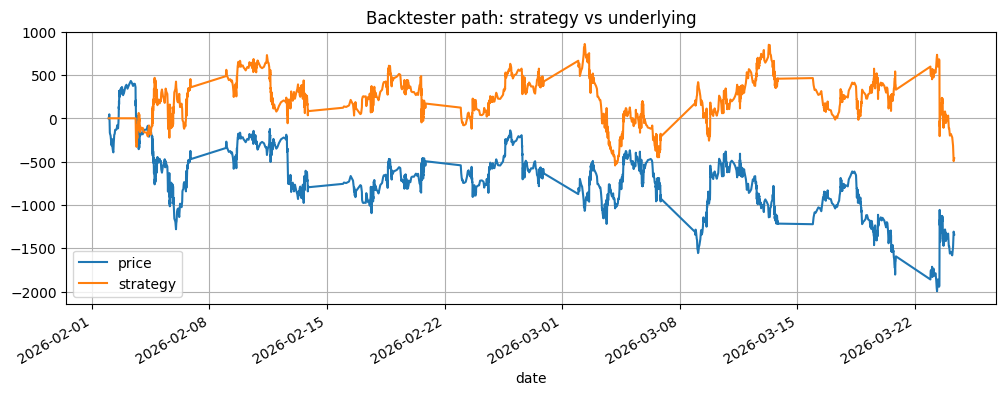

In [11]:
paths(result)[["price", "strategy"]].plot(
    figsize=(12, 4),
    grid=True,
    title="Backtester path: strategy vs underlying",
)